<a href="https://colab.research.google.com/github/quangkhaiva/Skin_Cancer_Detection/blob/main/CNN_Skin_Cancer_Detection_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Step 1. Data analysis and preprocessing

> Step 2. Model building

> Step 3. Model training

> Step 4. Model evaluation



In [ ]:
%matplotlib inline
# python libraties
import os, cv2,itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image

# pytorch libraries
import torch
from torch import optim,nn
from torch.autograd import Variable
from torch.utils.data import DataLoader,Dataset
from torchvision import models,transforms
import torch.nn.functional as F

# sklearn libraries
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve

# to make the results are reproducible
np.random.seed(10)
torch.manual_seed(10)
torch.cuda.manual_seed(10)

import multiprocessing
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


## Step 1. Data analysis and preprocessing

Nhận tất cả các đường dẫn dữ liệu hình ảnh, khớp thông tin hàng trong HAM10000_metadata.csv với hình ảnh tương ứng

In [ ]:
data_dir = '/content/drive/MyDrive/Skin_Cancer_Detection_Project/data'
all_image_path = glob(os.path.join(data_dir, '*', '*.jpg'))
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'dermatofibroma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

Hàm này được sử dụng để tính giá trị trung bình và độ lệch chuẩn trên toàn bộ tập dữ liệu, sẽ sử dụng để chuẩn hóa đầu vào

In [ ]:
def compute_img_mean_std(image_paths):

    img_h, img_w = 224, 224
    imgs = []
    means, stdevs = [], []

    for i in tqdm(range(len(image_paths))):
        img = cv2.imread(image_paths[i])
        img = cv2.resize(img, (img_h, img_w))
        imgs.append(img)

    imgs = np.stack(imgs, axis=3)
    print(imgs.shape)

    imgs = imgs.astype(np.float32) / 255.

    for i in range(3):
        pixels = imgs[:, :, i, :].ravel()  # thay đổi kích thước thành một hàng
        means.append(np.mean(pixels))
        stdevs.append(np.std(pixels))

    means.reverse()  # BGR --> RGB
    stdevs.reverse()

    print("normMean = {}".format(means))
    print("normStd = {}".format(stdevs))
    return means,stdevs

Trả về giá trị trung bình và original

In [ ]:
#norm_mean,norm_std = compute_img_mean_std(all_image_path)
norm_mean = [0.763038, 0.54564667, 0.57004464]
norm_std = [0.14092727, 0.15261286, 0.1699712]

In [ ]:
df_original = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))
df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)
df_original['cell_type_idx'] = pd.Categorical(df_original['cell_type']).codes

In [ ]:
df_original.isnull().sum()

lesion_id         0
image_id          0
dx                0
dx_type           0
age              57
sex               0
localization      0
path              0
cell_type         0
cell_type_idx     0
dtype: int64

In [ ]:
# Thay giá trị null bằng trung vị
df_original['age'].fillna((-1), inplace=True)

In [ ]:
# Mã hóa các nhãn
df_original['MR_dx_type'] = df_original['dx_type'].map(df_original['dx_type'].value_counts(dropna = False))
df_original['MR_age'] = df_original['age'].map(df_original['age'].value_counts(dropna = False))
df_original['MR_sex'] = df_original['sex'].map(df_original['sex'].value_counts(dropna = False))
df_original['MR_localization'] = df_original['localization'].map(df_original['localization'].value_counts(dropna = False))

In [ ]:
# Cho biết số ảnh liên kết lesion_id
df_undup = df_original.groupby('lesion_id').count()
# lọc các lesion_id chỉ 1 ảnh liên kết với nó
df_undup = df_undup[df_undup['image_id'] == 1]
df_undup.reset_index(inplace=True)
df_undup.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,MR_dx_type,MR_age,MR_sex,MR_localization
0,HAM_0000001,1,1,1,1,1,1,1,1,1,1,1,1,1
1,HAM_0000003,1,1,1,1,1,1,1,1,1,1,1,1,1
2,HAM_0000004,1,1,1,1,1,1,1,1,1,1,1,1,1
3,HAM_0000007,1,1,1,1,1,1,1,1,1,1,1,1,1
4,HAM_0000008,1,1,1,1,1,1,1,1,1,1,1,1,1


In [ ]:
# kiểm tra các lesion_id trùng lặp và lesion_id chỉ 1 ảnh liên kết với nó
def get_duplicates(x):
    unique_list = list(df_undup['lesion_id'])
    if x in unique_list:
        return 'unduplicated'
    else:
        return 'duplicated'

# tạo một cột mới là bản sao của cột _id lesion
df_original['duplicates'] = df_original['lesion_id']
df_original['duplicates'] = df_original['duplicates'].apply(get_duplicates)# áp dụng hàm cho cột mới này

In [ ]:
df_original['duplicates'].value_counts()

duplicates
unduplicated    5514
duplicated      4501
Name: count, dtype: int64

In [ ]:
# lọc hình ảnh không trùng lặp
df_undup = df_original[df_original['duplicates'] == 'unduplicated']
df_undup.shape

(5514, 15)

<Axes: xlabel='cell_type'>

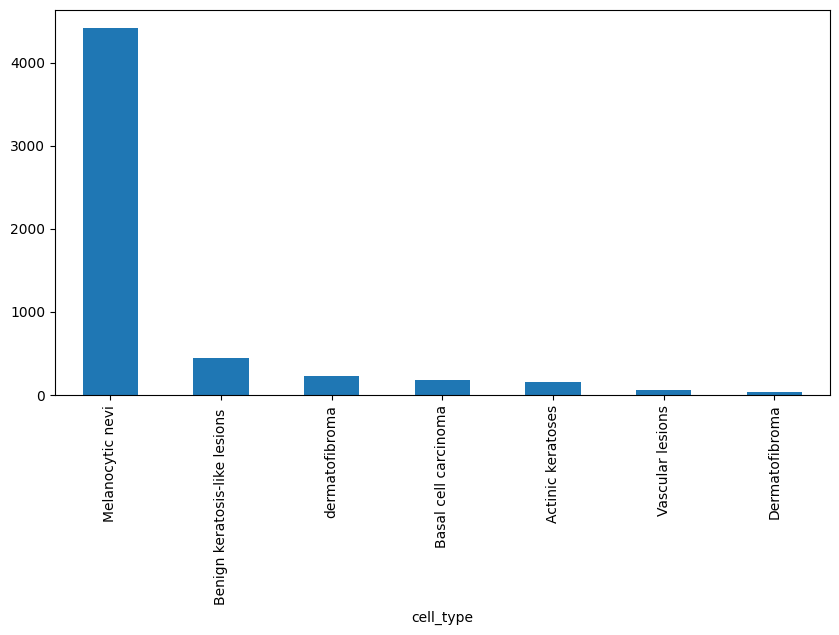

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
df_undup['cell_type'].value_counts().plot(kind='bar', ax=ax1)

In [ ]:
y = df_undup['cell_type_idx']
_, df_val = train_test_split(df_undup, test_size=0.2, random_state=101, stratify=y)
df_val.shape

(1103, 15)

In [ ]:
df_val['cell_type_idx'].value_counts()

cell_type_idx
4    883
2     88
6     46
1     35
0     30
5     13
3      8
Name: count, dtype: int64

<Axes: xlabel='cell_type'>

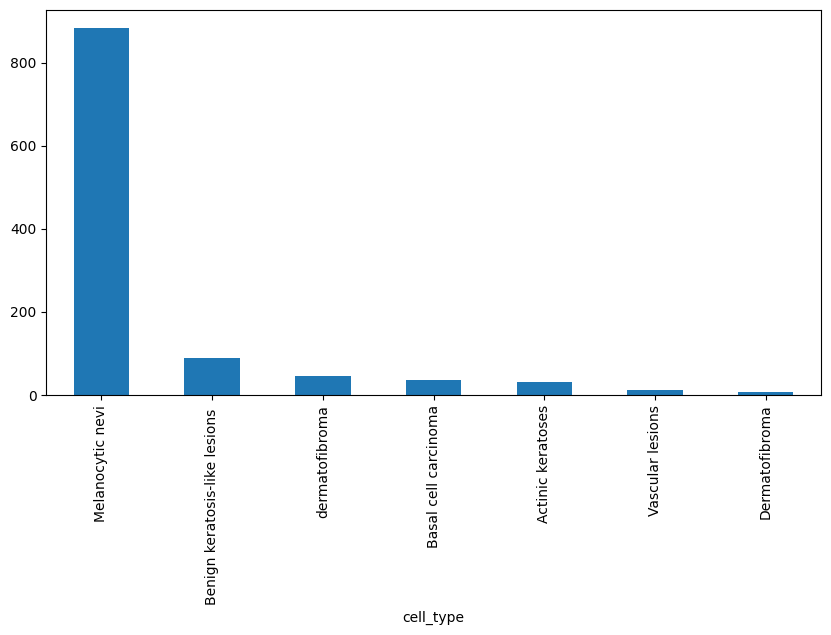

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
df_val['cell_type'].value_counts().plot(kind='bar', ax=ax1)

In [ ]:
# Hàm xác định xem một hình ảnh có phải là một phần của tập train hay tập val hay không.
def get_val_rows(x):
    # tạo danh sách tất cả các loss_id trong tập val
    val_list = list(df_val['image_id'])
    if str(x) in val_list:
        return 'val'
    else:
        return 'train'

# xác định các hàng train và val
# tạo một cột mới là bản sao của cột image_id
df_original['train_or_val'] = df_original['image_id']
df_original['train_or_val'] = df_original['train_or_val'].apply(get_val_rows)

df_train = df_original[df_original['train_or_val'] == 'train']# Lọc hàng train
print(len(df_train))
print(len(df_val))

8912
1103


In [ ]:
df_train['cell_type_idx'].value_counts()

cell_type_idx
4    5822
6    1067
2    1011
1     479
0     297
5     129
3     107
Name: count, dtype: int64

<Axes: xlabel='cell_type'>

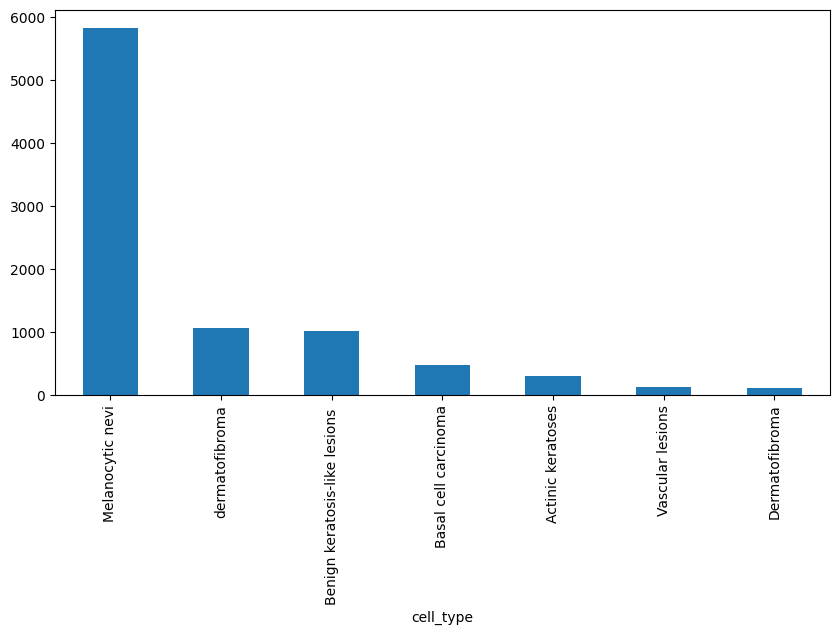

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
df_train['cell_type'].value_counts().plot(kind='bar', ax=ax1)

In [ ]:
df_val['cell_type'].value_counts()

cell_type
Melanocytic nevi                  883
Benign keratosis-like lesions      88
dermatofibroma                     46
Basal cell carcinoma               35
Actinic keratoses                  30
Vascular lesions                   13
Dermatofibroma                      8
Name: count, dtype: int64

In [ ]:
df_train = df_train.reset_index()
df_val = df_val.reset_index()
# df_test = df_test.reset_index()

In [ ]:
df_train.head()

,index,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,MR_dx_type,MR_age,MR_sex,MR_localization,duplicates,train_or_val
0,0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Benign keratosis-like lesions,2,5340,404,5406,128,duplicated,train
1,1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Benign keratosis-like lesions,2,5340,404,5406,128,duplicated,train
2,2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Benign keratosis-like lesions,2,5340,404,5406,128,duplicated,train
3,3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Benign keratosis-like lesions,2,5340,404,5406,128,duplicated,train
4,4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Benign keratosis-like lesions,2,5340,618,5406,56,duplicated,train


In [ ]:
df_val.head()

,index,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,MR_dx_type,MR_age,MR_sex,MR_localization,duplicates
0,4781,HAM_0000199,ISIC_0026127,nv,follow_up,55.0,male,lower extremity,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Melanocytic nevi,4,3704,1009,5406,2077,unduplicated
1,3294,HAM_0006655,ISIC_0025994,nv,follow_up,50.0,female,lower extremity,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Melanocytic nevi,4,3704,1187,4552,2077,unduplicated
2,2089,HAM_0006004,ISIC_0027702,mel,histo,70.0,female,back,/content/drive/MyDrive/Skin_Cancer_Detection_P...,dermatofibroma,6,5340,756,4552,2192,unduplicated
3,9816,HAM_0004563,ISIC_0031211,akiec,histo,75.0,male,lower extremity,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Actinic keratoses,0,5340,618,5406,2077,unduplicated
4,8611,HAM_0004275,ISIC_0026921,nv,histo,70.0,female,back,/content/drive/MyDrive/Skin_Cancer_Detection_P...,Melanocytic nevi,4,5340,756,4552,2192,unduplicated


<Axes: xlabel='cell_type'>

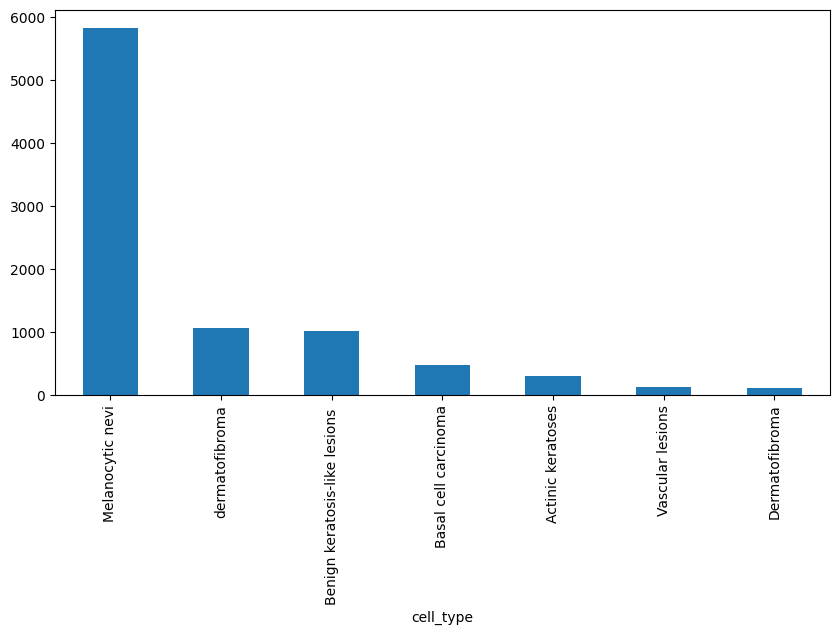

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
df_train['cell_type'].value_counts().plot(kind='bar', ax=ax1)

## Step 2. Model building

In [ ]:
class CNN_WRAP(nn.Module):
  def __init__(self, model_ft):
    super(CNN_WRAP, self).__init__()
    self.cnn_out = model_ft

    self.mr1 = nn.Linear(3, 8)
    self.mr1_bn = nn.BatchNorm1d(8)
    self.mr1_drop = nn.Dropout(0.5)


    self.fc1 = nn.Linear(24, 7)

  def forward(self, x, mr):
    y_cnn = self.cnn_out(x)

    y_mr = F.relu(self.mr1_drop(self.mr1_bn(self.mr1(mr))))
    x = self.fc1(torch.cat((y_cnn, y_mr), 1))
    return F.log_softmax(x, dim=1)


In [ ]:
# Nếu feature_extract = False, mô hình đã được tinh chỉnh và tất cả các tham số mô hình được cập nhật.
# Nếu feature_extract = True, chỉ các tham số lớp cuối cùng được cập nhật, các tham số khác vẫn cố định.
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [ ]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0

    if model_name == "resnet":
        """ Resnet18, resnet34, resnet50, resnet101
        """
        model_ft = models.resnet50(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)
        input_size = 224


    elif model_name == "vgg":
        """ VGG11_bn
        """
        model_ft = models.vgg11_bn(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs,num_classes)
        input_size = 224


    elif model_name == "densenet":
        """ Densenet121
        """
        model_ft = models.densenet121(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "inception":
        """ Inception v3
        Be careful, expects (299,299) sized images and has auxiliary output
        """
        model_ft = models.inception_v3(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        # Handle the auxilary net
        num_ftrs = model_ft.AuxLogits.fc.in_features
        model_ft.AuxLogits.fc = nn.Linear(num_ftrs, num_classes)
        # Handle the primary net
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs,num_classes)
        input_size = 299

    elif model_name == "custom":
      model_ft = DeepCNN()
      input_size = 224

    else:
        print("Invalid model name, exiting...")
        exit()

    model_ft = CNN_WRAP(model_ft)

    return model_ft, input_size

In [ ]:
#khởi tạo một mô hình CNN dựa trên kiến trúc densenet
# resnet,vgg,densenet,inception
model_name = 'densenet'
num_classes = 16
feature_extract = False
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)
device = torch.device('cuda:0')
# đưa mô hình vào model:
model = model_ft.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 44.2MB/s]


In [ ]:
# define the transformation of the train images.
train_transform = transforms.Compose([transforms.Resize((input_size,input_size)),transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),transforms.RandomRotation(20),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
                                        transforms.ToTensor(), transforms.Normalize(norm_mean, norm_std)])
# define the transformation of the val images.
val_transform = transforms.Compose([transforms.Resize((input_size,input_size)), transforms.ToTensor(),
                                    transforms.Normalize(norm_mean, norm_std)])

In [ ]:
# Define a pytorch dataloader for this dataset
class HAM10000(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load data and get label
        X = Image.open(self.df['path'][index])
        MR = torch.FloatTensor([self.df[feat][index] for feat in ['MR_age', 'MR_sex', 'MR_localization']])
        y = torch.tensor(int(self.df['cell_type_idx'][index]))

        if self.transform:
            X = self.transform(X)

        return X, MR, y

In [ ]:
# Xác định tập huấn luyện bằng train_df và sử dụng train_transform
n_workers = multiprocessing.cpu_count()
training_set = HAM10000(df_train, transform=train_transform)
train_loader = DataLoader(training_set, batch_size=32, shuffle=True, num_workers=n_workers)

validation_set = HAM10000(df_val, transform=train_transform)
val_loader = DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=n_workers)

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=0, alpha=None, size_average=True):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        if isinstance(alpha,(float,int)): self.alpha = torch.Tensor([alpha,1-alpha])
        if isinstance(alpha,list): self.alpha = torch.Tensor(alpha)
        self.size_average = size_average

    def forward(self, input, target):
        if input.dim()>2:
            input = input.view(input.size(0),input.size(1),-1)  # N,C,H,W => N,C,H*W
            input = input.transpose(1,2)    # N,C,H*W => N,H*W,C
            input = input.contiguous().view(-1,input.size(2))   # N,H*W,C => N*H*W,C
        target = target.view(-1,1)

        logpt = F.log_softmax(input, dim=1)
        logpt = logpt.gather(1,target)
        logpt = logpt.view(-1)
        pt = Variable(logpt.data.exp())

        if self.alpha is not None:
            if self.alpha.type()!=input.data.type():
                self.alpha = self.alpha.type_as(input.data)
            at = self.alpha.gather(0,target.data.view(-1))
            logpt = logpt * Variable(at)

        loss = -1 * (1-pt)**self.gamma * logpt
        if self.size_average: return loss.mean()
        else: return loss.sum()

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
#criterion = nn.CrossEntropyLoss().to(device)
criterion = FocalLoss(gamma=2.0).to(device)

## Step 3. Model training

In [ ]:
# class để tính toán tổn thất và độ chính xác
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [ ]:
total_loss_train, total_acc_train = [],[]
def train(train_loader, model, criterion, optimizer, epoch):
    model.train()
    train_loss = AverageMeter()
    train_acc = AverageMeter()
    curr_iter = (epoch - 1) * len(train_loader)
    for i, data in enumerate(train_loader):
        images, mr, labels = data
        N = images.size(0)
        # print('image shape:',images.size(0), 'label shape',labels.size(0))
        images = Variable(images).to(device)
        labels = Variable(labels).to(device)
        mr = Variable(mr).to(device)

        optimizer.zero_grad()
        outputs = model(images, mr)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        prediction = outputs.max(1, keepdim=True)[1]
        train_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)
        train_loss.update(loss.item())
        curr_iter += 1
        '''
        print('[epoch %d], [iter %d / %d], [train loss %.5f], [train acc %.5f]' % (
            epoch, i + 1, len(train_loader), train_loss.avg, train_acc.avg))
        total_loss_train.append(train_loss.avg)
        total_acc_train.append(train_acc.avg)
        '''

        if (i + 1) % 50 == 0:
            print('[epoch %d], [iter %d / %d], [train loss %.5f], [train acc %.5f]' % (
                epoch, i + 1, len(train_loader), train_loss.avg, train_acc.avg))
            total_loss_train.append(train_loss.avg)
            total_acc_train.append(train_acc.avg)

    return train_loss.avg, train_acc.avg

In [ ]:
def validate(val_loader, model, criterion, optimizer, epoch):
    model.eval()
    val_loss = AverageMeter()
    val_acc = AverageMeter()
    with torch.no_grad():
        for i, data in enumerate(val_loader):
            images, mr, labels = data
            N = images.size(0)
            images = Variable(images).to(device)
            labels = Variable(labels).to(device)
            mr = Variable(mr).to(device)

            outputs = model(images, mr)
            prediction = outputs.max(1, keepdim=True)[1]

            val_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)

            val_loss.update(criterion(outputs, labels).item())

    print('------------------------------------------------------------')
    print('[epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, val_loss.avg, val_acc.avg))
    print('------------------------------------------------------------')
    return val_loss.avg, val_acc.avg

In [ ]:
save_dir = '/content/drive/MyDrive/Skin_Cancer_Detection_Project2/Model'
model_name = 'CNN_Skin_Cancer_Detection_Project'
start_from_checkpoint = False
start_epoch = 1
#Create Save Path from save_dir and model_name, we will save and load our checkpoint here
save_path = os.path.join(save_dir, model_name + ".pt")

#Create the save directory if it does note exist
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)

if start_from_checkpoint:
    if os.path.isfile(save_path):
        check_point = torch.load(save_path)
        model.load_state_dict(check_point['model_state_dict'])
        optimizer.load_state_dict(check_point['optimizer_state_dict'])
        start_epoch = check_point['epoch']
        print("Checkpoint loaded, starting from epoch:", start_epoch)
    else:
        raise ValueError("Checkpoint Does not exist")#Đưa ra lỗi nếu nó không tồn tại
else:
    #Nếu điểm kiểm tra tồn tại và Start_From_Checkpoint = Sai
    #Đưa ra lỗi để tránh bị trùng
    if os.path.isfile(save_path):
        raise ValueError("Warning Checkpoint exists")
    else:
        print("Starting from scratch")

Starting from scratch


[epoch 1], [iter 50 / 279], [train loss 0.70372], [train acc 0.61938]
[epoch 1], [iter 100 / 279], [train loss 0.63767], [train acc 0.64375]
[epoch 1], [iter 150 / 279], [train loss 0.61061], [train acc 0.65021]
[epoch 1], [iter 200 / 279], [train loss 0.57991], [train acc 0.66031]
[epoch 1], [iter 250 / 279], [train loss 0.57501], [train acc 0.65838]
------------------------------------------------------------
[epoch 1], [val loss 0.27534], [val acc 0.84006]
------------------------------------------------------------
*****************************************************
best record: [epoch 1], [val loss 0.27534], [val acc 0.84006]
*****************************************************
[epoch 2], [iter 50 / 279], [train loss 0.48195], [train acc 0.69312]
[epoch 2], [iter 100 / 279], [train loss 0.47849], [train acc 0.69656]
[epoch 2], [iter 150 / 279], [train loss 0.48127], [train acc 0.68854]
[epoch 2], [iter 200 / 279], [train loss 0.47771], [train acc 0.69234]
[epoch 2], [iter 250 /

## Step 4. Model evaluation

In [ ]:
def plot_acc(num_epochs, training_acc_logger, validation_acc_logger):
  plt.figure(figsize = (10,10))
  train_x = np.linspace(0, num_epochs, len(training_acc_logger))
  plt.plot(train_x, training_acc_logger, c = "y")
  valid_x = np.linspace(0, num_epochs, len(validation_acc_logger))
  plt.plot(valid_x, validation_acc_logger, c = "k")

  plt.title('Accuracy')
  plt.legend(["Training Acc", "Validation Acc"])
  plt.show()

def plot_result(num_epochs, training_loss_logger, validation_loss_logger):
  #plot out the training_loss_logger and validation_loss_logger
  plt.figure(figsize = (10,10))
  train_x = np.linspace(0, num_epochs, len(training_loss_logger))
  plt.plot(train_x, training_loss_logger, c = "y")
  valid_x = np.linspace(0, num_epochs, len(validation_loss_logger))
  plt.plot(valid_x, validation_loss_logger, c = "k")

  plt.title(f'Epoch: {num_epochs}')
  plt.legend(["Training Loss", "Validation Loss"])
  plt.ylim(0, 5)
  plt.show()

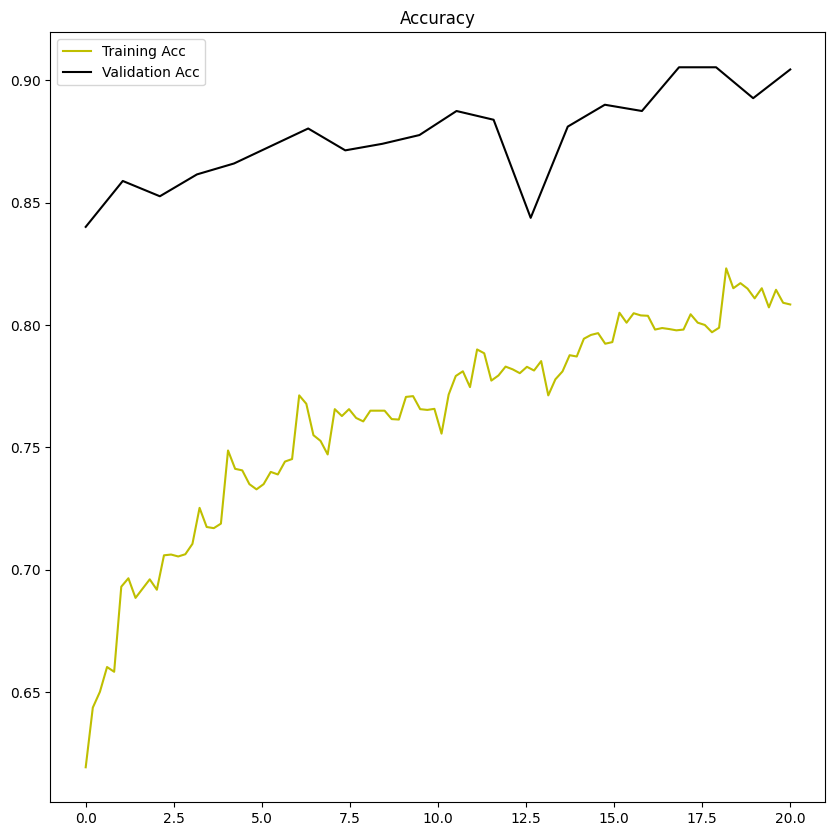

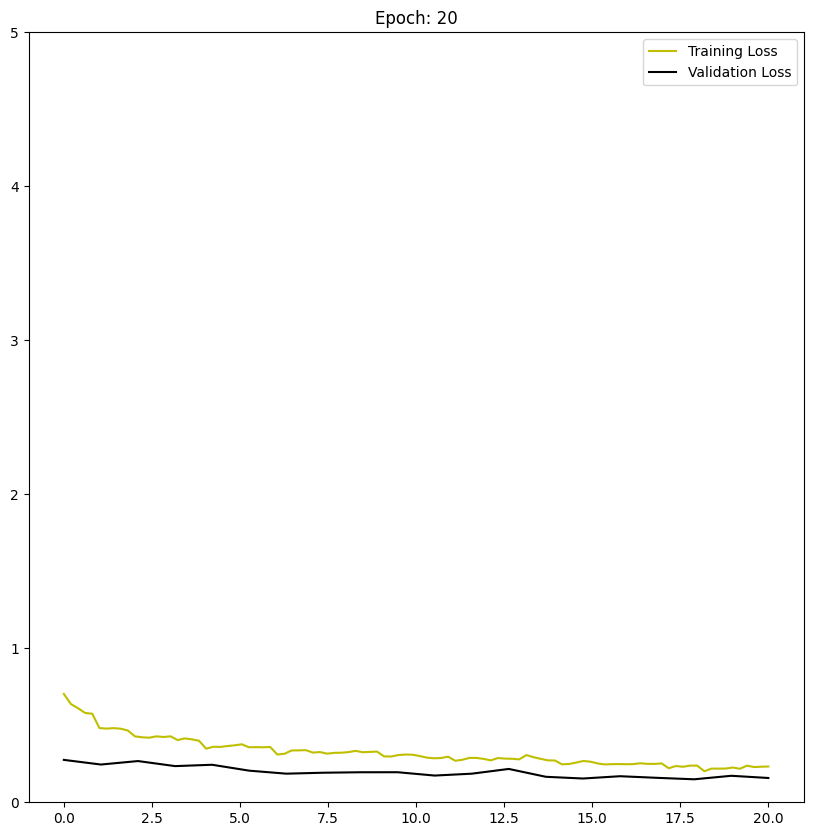

In [ ]:
plot_acc(20, total_acc_train, total_acc_val)
plot_result(20, total_loss_train, total_loss_val)

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

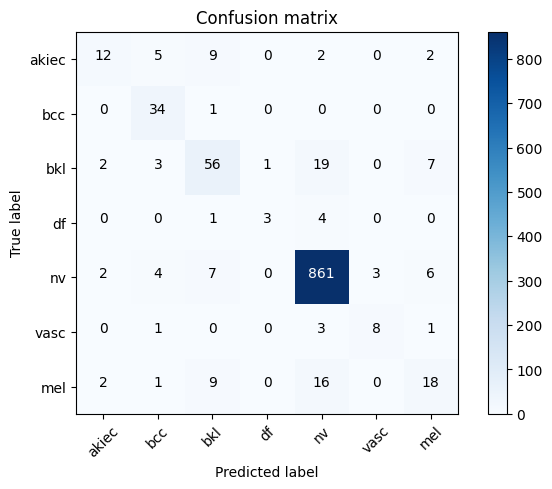

In [ ]:
model.eval()
y_label = []
y_predict = []
with torch.no_grad():
    for i, data in enumerate(val_loader):
        images, mr, labels = data
        N = images.size(0)
        images = Variable(images).to(device)
        mr = Variable(mr).to(device)
        outputs = model(images, mr)
        prediction = outputs.max(1, keepdim=True)[1]
        y_label.extend(labels.cpu().numpy())
        y_predict.extend(np.squeeze(prediction.cpu().numpy().T))

# compute the confusion matrix
confusion_mtx = confusion_matrix(y_label, y_predict)
# plot the confusion matrix
plot_labels = ['akiec', 'bcc', 'bkl', 'df', 'nv', 'vasc','mel']
plot_confusion_matrix(confusion_mtx, plot_labels)

In [ ]:
# Generate a classification report
report = classification_report(y_label, y_predict, target_names=plot_labels)
print(report)

              precision    recall  f1-score   support

       akiec       0.67      0.40      0.50        30
         bcc       0.71      0.97      0.82        35
         bkl       0.67      0.64      0.65        88
          df       0.75      0.38      0.50         8
          nv       0.95      0.98      0.96       883
        vasc       0.73      0.62      0.67        13
         mel       0.53      0.39      0.45        46

    accuracy                           0.90      1103
   macro avg       0.72      0.62      0.65      1103
weighted avg       0.89      0.90      0.89      1103



Text(0, 0.5, 'Fraction classified incorrectly')

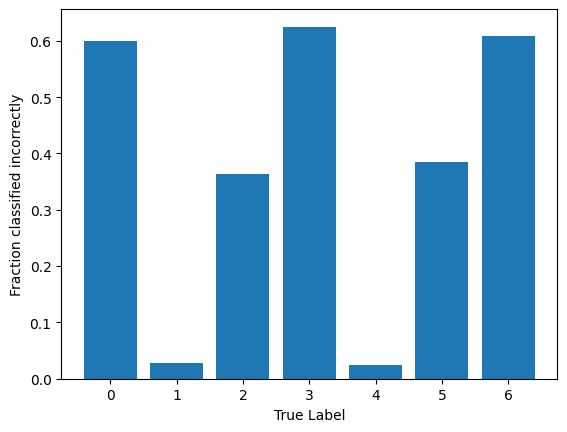

In [ ]:
label_frac_error = 1 - np.diag(confusion_mtx) / np.sum(confusion_mtx, axis=1)
plt.bar(np.arange(7),label_frac_error)
plt.xlabel('True Label')
plt.ylabel('Fraction classified incorrectly')

In [ ]:
from sklearn.preprocessing import LabelBinarizer
def multiclass_roc_auc_score(y_test, y_pred, average="macro"):
  lb = LabelBinarizer()
  lb.fit(y_test)
  y_test = lb.transform(y_test)
  y_pred = lb.transform(y_pred)
  return roc_auc_score(y_test, y_pred, average=average)

multiclass_roc_auc_score(y_label, y_predict)

0.7928901424484939